In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_csv('Nassau_Candy_Distributor1.csv')

In [3]:
#check the first few rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
#get an overview of data structure and the data types
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


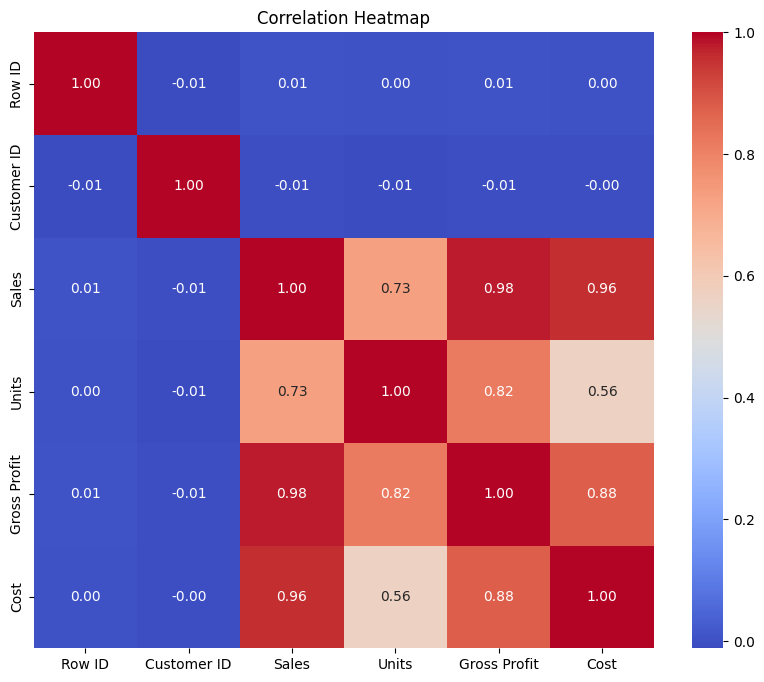

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#compute correlation matrix
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

#plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True ,cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [6]:
#create a pivot table to analyze average sales by product
pivot_table = df.pivot_table(values= 'Sales', index= 'Product Name', aggfunc='mean')
print(pivot_table)

                                       Sales
Product Name                                
Everlasting Gobstopper             43.333333
Fizzy Lifting Drinks               13.125000
Fun Dip                             4.000000
Hair Toffee                        19.125000
Kazookles                          12.559896
Laffy Taffy                         5.373000
Lickable Wallpaper                 83.617021
Nerds                               3.750000
SweeTARTS                           6.150000
Wonka Bar - Fudge Mallows          13.691089
Wonka Bar - Milk Chocolate         12.572649
Wonka Bar - Nutty Crunch Surprise  13.024834
Wonka Bar - Triple Dazzle Caramel  14.136476
Wonka Bar -Scrumdiddlyumptious     13.505233
Wonka Gum                           4.979167


In [7]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')


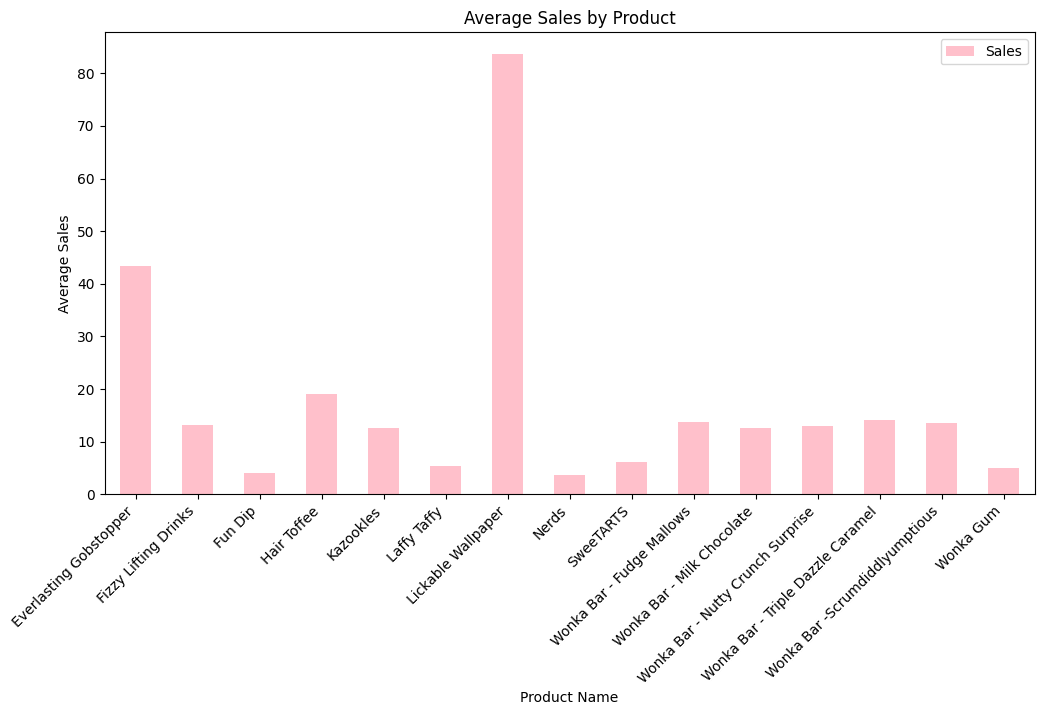

In [8]:
#visualize average sales by product using a bar chart
pivot_table.plot(kind='bar', figsize=(12,6), color='pink')
plt.title('Average Sales by Product')
plt.xlabel('Product Name')
plt.ylabel('Average Sales')
plt.xticks(rotation=45 , ha='right')
plt.show()

In [9]:
#summarize total sales and average gross profit by product to evaluate the performance by category
factory_summary = df.groupby('Product Name').agg({'Sales': 'sum', 'Gross Profit': 'mean'})
print(factory_summary)

                                      Sales  Gross Profit
Product Name                                             
Everlasting Gobstopper               130.00     34.666667
Fizzy Lifting Drinks                  78.75      7.875000
Fun Dip                               12.00      1.600000
Hair Toffee                           76.50     14.875000
Kazookles                           1205.75      0.966146
Laffy Taffy                           53.73      3.348000
Lickable Wallpaper                  7860.00     41.808511
Nerds                                 15.00      1.750000
SweeTARTS                             61.50      2.870000
Wonka Bar - Fudge Mallows          24890.40      9.127393
Wonka Bar - Milk Chocolate         26867.75      8.162550
Wonka Bar - Nutty Crunch Surprise  23574.95      9.292790
Wonka Bar - Triple Dazzle Caramel  28485.00      9.235831
Wonka Bar -Scrumdiddlyumptious     27874.80      9.378634
Wonka Gum                            597.50      2.589167


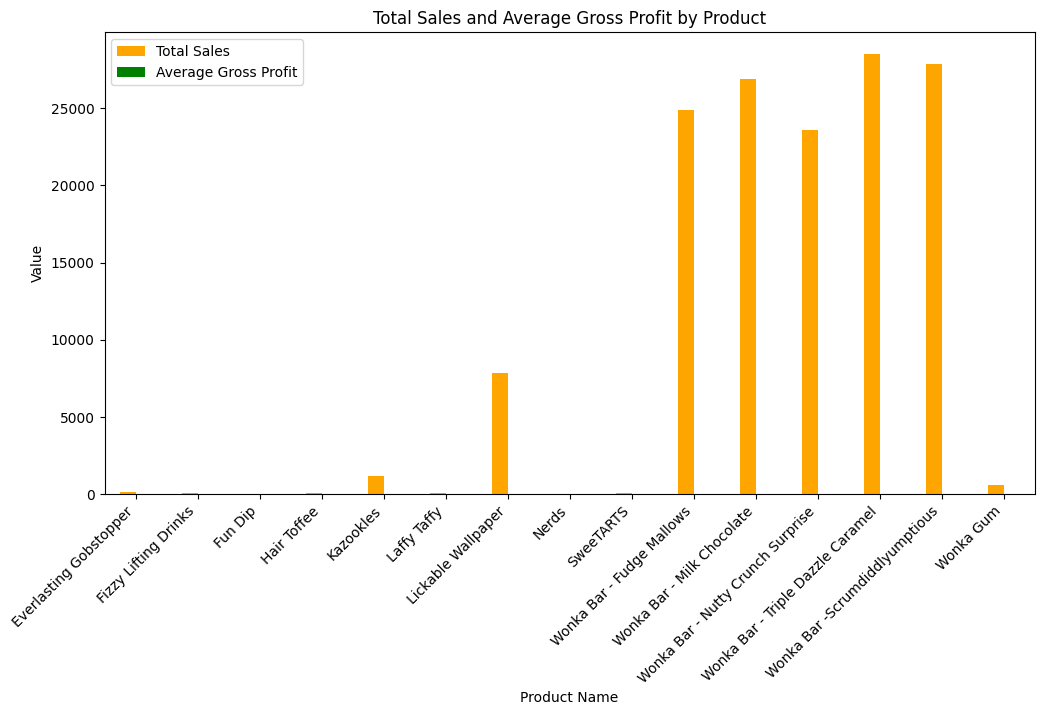

In [10]:
#summarize the total sales and average gross profit by product to evaluate product-level performance
product_summary = df.groupby('Product Name').agg({'Sales': 'sum', 'Gross Profit': 'mean'})
product_summary.plot(kind='bar', figsize=(12,6), color=['orange','green'])
plt.title('Total Sales and Average Gross Profit by Product')
plt.xlabel('Product Name')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.legend(['Total Sales', 'Average Gross Profit'])
plt.show()

In [11]:
#sort products by total sales in descending order to identify top performers
product_summary = product_summary.sort_values(by='Sales', ascending=False)
print(product_summary)

                                      Sales  Gross Profit
Product Name                                             
Wonka Bar - Triple Dazzle Caramel  28485.00      9.235831
Wonka Bar -Scrumdiddlyumptious     27874.80      9.378634
Wonka Bar - Milk Chocolate         26867.75      8.162550
Wonka Bar - Fudge Mallows          24890.40      9.127393
Wonka Bar - Nutty Crunch Surprise  23574.95      9.292790
Lickable Wallpaper                  7860.00     41.808511
Kazookles                           1205.75      0.966146
Wonka Gum                            597.50      2.589167
Everlasting Gobstopper               130.00     34.666667
Fizzy Lifting Drinks                  78.75      7.875000
Hair Toffee                           76.50     14.875000
SweeTARTS                             61.50      2.870000
Laffy Taffy                           53.73      3.348000
Nerds                                 15.00      1.750000
Fun Dip                               12.00      1.600000


In [12]:
#filter and analyze details of top 3 performing products to see factory or regional associations
top_products = product_summary.head(3)
top_products_details = df[df['Product Name'].isin(top_products.index)]
print(top_products_details)

       Row ID                      Order ID  Order Date   Ship Date  \
0           1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1           2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
3           4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4           5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   
5           6  US-2021-167199-CHO-SCR-58000  06-01-2024  03-07-2026   
...       ...                           ...         ...         ...   
10188   10189  US-2024-115427-CHO-TRI-54000  30-12-2025  26-06-2030   
10189   10190  US-2024-143259-CHO-MIL-31000  30-12-2025  26-06-2030   
10191   10192  US-2024-156720-CHO-SCR-58000  30-12-2025  26-06-2030   
10192   10193  US-2024-143259-CHO-TRI-54000  30-12-2025  26-06-2030   
10193   10194  CA-2024-143500-CHO-SCR-58000  30-12-2025  26-06-2030   

            Ship Mode  Customer ID Country/Region           City  \
0      Standard Class       103800  United States        Houston   
1      Stan

In [13]:
#example : reassign top products to an alternate factory and simulate new lead times
top_products = product_summary.head(3).index

for product in top_products:
  #filter rows of that product:
  product_rows = df[df['Product Name'] == product]

  #assign to an alternate factory (based on some logic, e.g., the second factory in the list)
  df.loc[product_rows.index, 'Factory'] = 'Alternate Factory' #replace with logic

In [14]:
#evaluate impact of factory reassignment on average gross profit and total sales by factory
factory_impact = df.groupby('Factory').agg({'Gross Profit': 'mean', 'Sales': 'mean'})
print(factory_impact)

                   Gross Profit      Sales
Factory                                   
Alternate Factory      8.914265  13.389245


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalize Gross Profit and Sales
scaler = MinMaxScaler()
factory_impact[['Gross Profit Norm', 'Sales Norm']] = scaler.fit_transform(factory_impact[['Gross Profit', 'Sales']])

# Create a combined score (you can adjust weights)
factory_impact['Combined Score'] = factory_impact['Gross Profit Norm'] + factory_impact['Sales Norm']

# Rank by the combined score
factory_impact = factory_impact.sort_values(by='Combined Score', ascending=False)
print(factory_impact)

                   Gross Profit      Sales  Gross Profit Norm  Sales Norm  \
Factory                                                                     
Alternate Factory      8.914265  13.389245                0.0         0.0   

                   Combined Score  
Factory                            
Alternate Factory             0.0  


In [16]:
#recommend top N factories based on combined performance score
top_factories = factory_impact.head(3)
print(top_factories)

                   Gross Profit      Sales  Gross Profit Norm  Sales Norm  \
Factory                                                                     
Alternate Factory      8.914265  13.389245                0.0         0.0   

                   Combined Score  
Factory                            
Alternate Factory             0.0  


In [17]:
#compile executive summary report with top factory recommendations and key performance insights
with open('executive_summary.txt', 'w') as f:
    f.write("Top Factory Recommendations:\n")
    f.write(top_factories.to_string())
    f.write("\nKey Performance Indicators and Analysis...")

In [18]:
# data preparation and encoding for machine learning model

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create copy of dataset
model_df = df.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

model_df['Ship Mode'] = label_encoder.fit_transform(model_df['Ship Mode'])
model_df['Region'] = label_encoder.fit_transform(model_df['Region'])
model_df['Division'] = label_encoder.fit_transform(model_df['Division'])

# Select numeric columns for scaling
numeric_columns = ['Sales', 'Units', 'Gross Profit', 'Cost']

# Normalize numerical features
scaler = StandardScaler()
model_df[numeric_columns] = scaler.fit_transform(model_df[numeric_columns])

# Display first few rows
model_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,3,103800,United States,Houston,Texas,77095,0,2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,-0.653283,-0.804161,-0.744565,-0.486444,Alternate Factory
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,3,112326,United States,Naperville,Illinois,60540,0,2,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,-0.565104,-0.804161,-0.642208,-0.423220,Alternate Factory
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,3,112326,United States,Naperville,Illinois,60540,0,2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,-0.303210,-0.355370,-0.255358,-0.344191,NaN
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,3,112326,United States,Naperville,Illinois,60540,0,2,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,-0.274110,-0.355370,-0.250843,-0.284919,Alternate Factory
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,3,141817,United States,Philadelphia,Pennsylvania,19143,0,0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,-0.234429,-0.355370,-0.273421,-0.166374,Alternate Factory


In [19]:
# build Linear Regression Model for sales performance

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select input features
X = model_df[['Units', 'Cost', 'Ship Mode', 'Region', 'Division']]

# Select target variable
y = model_df['Sales']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict values
linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:5])


[-0.26867587 -0.87960582 -0.21550052  0.05217764 -0.3157416 ]


In [20]:
# build Random Forest Regressor Model for sales performance

from sklearn.ensemble import RandomForestRegressor

# Create random forest model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
random_forest_model.fit(X_train, y_train)

# Predict values
random_forest_predictions = random_forest_model.predict(X_test)

# Display first 5 predictions
print(random_forest_predictions[:5])

[-0.27411026 -0.89577799 -0.23442934  0.04333709 -0.27411026]


In [21]:
# build Gradiant Boosting Regressor Model for sales performance

from sklearn.ensemble import GradientBoostingRegressor

# Create gradient boosting model
gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

# Train model
gradient_boosting_model.fit(X_train, y_train)

# Predict values
gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

# Display first 5 predictions
print(gradient_boosting_predictions[:5])

[-0.27457393 -0.89092361 -0.24007849  0.00546196 -0.31187384]


In [22]:
# evaluate model performance using RMSE, MAE and R2 Score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression Metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

# Random Forest Metrics
rf_mae = mean_absolute_error(y_test, random_forest_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
rf_r2 = r2_score(y_test, random_forest_predictions)

# Gradient Boosting Metrics
gb_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gradient_boosting_predictions))
gb_r2 = r2_score(y_test, gradient_boosting_predictions)

# Display results
print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

print("\nRandom Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

print("\nGradient Boosting Regressor")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

Linear Regression
MAE: 0.0644330276000384
RMSE: 0.14950841436606974
R2 Score: 0.9725423229467338

Random Forest Regressor
MAE: 0.0012966022843814908
RMSE: 0.016712983478712584
R2 Score: 0.999656884379971

Gradient Boosting Regressor
MAE: 0.031661057906447965
RMSE: 0.05129766141587353
R2 Score: 0.9967675809685768


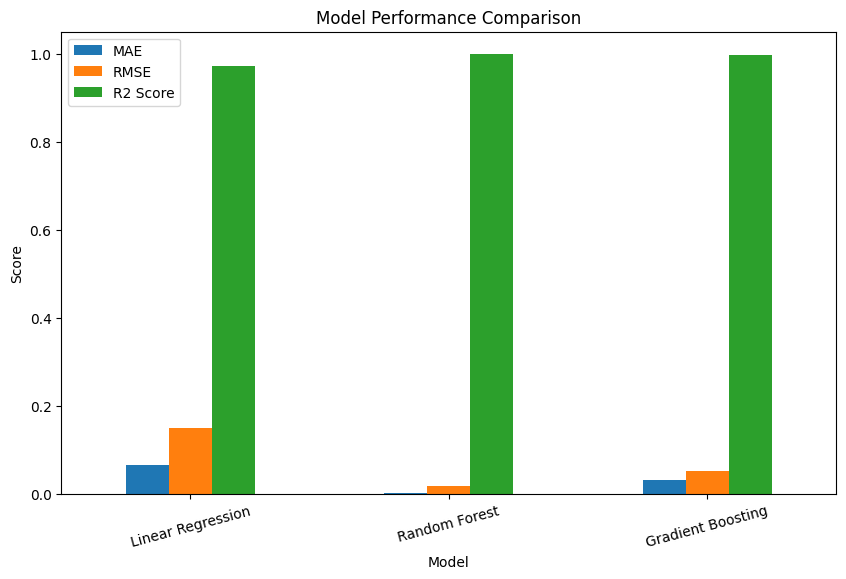

In [23]:
#compare model performance using bar chart

import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe for model comparison
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [linear_mae, rf_mae, gb_mae],
    'RMSE': [linear_rmse, rf_rmse, gb_rmse],
    'R2 Score': [linear_r2, rf_r2, gb_r2]
})

# Set model name as index
model_results.set_index('Model', inplace=True)

# Plot bar chart
model_results.plot(kind='bar', figsize=(10,6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.show()

In [24]:
# analyze product performance across regions
# Group product performance by region
region_product_summary = df.groupby(['Region', 'Product Name']).agg({
    'Sales': 'sum',
    'Gross Profit': 'mean',
    'Units': 'sum'
}).reset_index()

# Display first rows
print(region_product_summary.head())

     Region          Product Name   Sales  Gross Profit  Units
0  Atlantic  Fizzy Lifting Drinks   33.75     10.125000      9
1  Atlantic               Fun Dip    6.00      2.400000      4
2  Atlantic           Hair Toffee   22.50     17.500000      5
3  Atlantic             Kazookles  484.25      1.006757    149
4  Atlantic           Laffy Taffy   27.86      2.893333     14


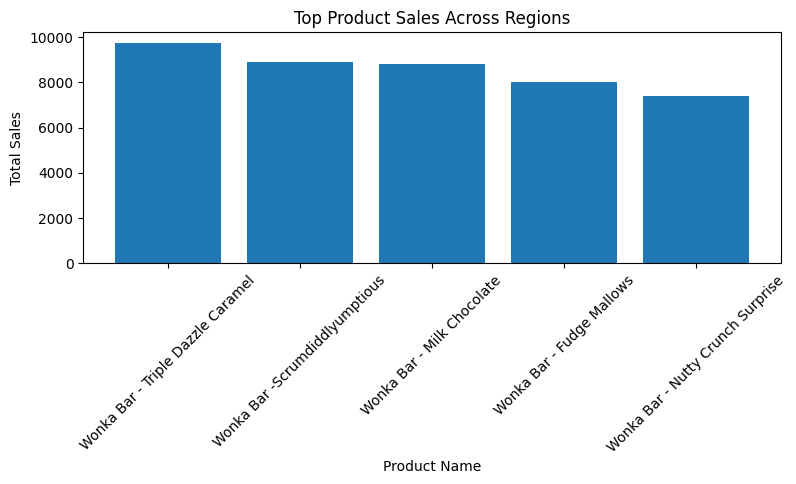

In [25]:
# Visualize sales performance of products across regions

import matplotlib.pyplot as plt

# Get top 10 product-region combinations by sales
top_region_products = region_product_summary.sort_values(
    by='Sales',
    ascending=False
).head(10)

# Plot chart
plt.figure(figsize=(9,3))

plt.bar(
    top_region_products['Product Name'],
    top_region_products['Sales']
)

plt.title('Top Product Sales Across Regions')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [26]:
# generate product optimization recommendations based on sales and gross profit
# Create product recommendation summary
recommendation_summary = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'mean',
    'Units': 'sum'
}).reset_index()

# Create recommendation score
recommendation_summary['Recommendation Score'] = (
    recommendation_summary['Sales'] +
    recommendation_summary['Gross Profit'] * 100
)

# Rank products
recommendation_summary = recommendation_summary.sort_values(
    by='Recommendation Score',
    ascending=False
)

# Show top 10 recommendations
print(recommendation_summary.head(10))

                         Product Name     Sales  Gross Profit  Units  \
12  Wonka Bar - Triple Dazzle Caramel  28485.00      9.235831   7596   
13     Wonka Bar -Scrumdiddlyumptious  27874.80      9.378634   7743   
10         Wonka Bar - Milk Chocolate  26867.75      8.162550   8267   
9           Wonka Bar - Fudge Mallows  24890.40      9.127393   6914   
11  Wonka Bar - Nutty Crunch Surprise  23574.95      9.292790   6755   
6                  Lickable Wallpaper   7860.00     41.808511    393   
0              Everlasting Gobstopper    130.00     34.666667     13   
3                         Hair Toffee     76.50     14.875000     17   
4                           Kazookles   1205.75      0.966146    371   
1                Fizzy Lifting Drinks     78.75      7.875000     21   

    Recommendation Score  
12          29408.583127  
13          28812.663372  
10          27684.005030  
9           25803.139274  
11          24504.229006  
6           12040.851064  
0            3596.

In [27]:
# cluster products and regions based on sales, units and gross profit

from sklearn.cluster import KMeans

# Select clustering features
clustering_data = region_product_summary[
    ['Sales', 'Units', 'Gross Profit']
]

# Create clustering model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model and assign clusters
region_product_summary['Cluster'] = kmeans.fit_predict(clustering_data)

# Display first rows
print(region_product_summary.head())

     Region          Product Name   Sales  Gross Profit  Units  Cluster
0  Atlantic  Fizzy Lifting Drinks   33.75     10.125000      9        0
1  Atlantic               Fun Dip    6.00      2.400000      4        0
2  Atlantic           Hair Toffee   22.50     17.500000      5        0
3  Atlantic             Kazookles  484.25      1.006757    149        0
4  Atlantic           Laffy Taffy   27.86      2.893333     14        0


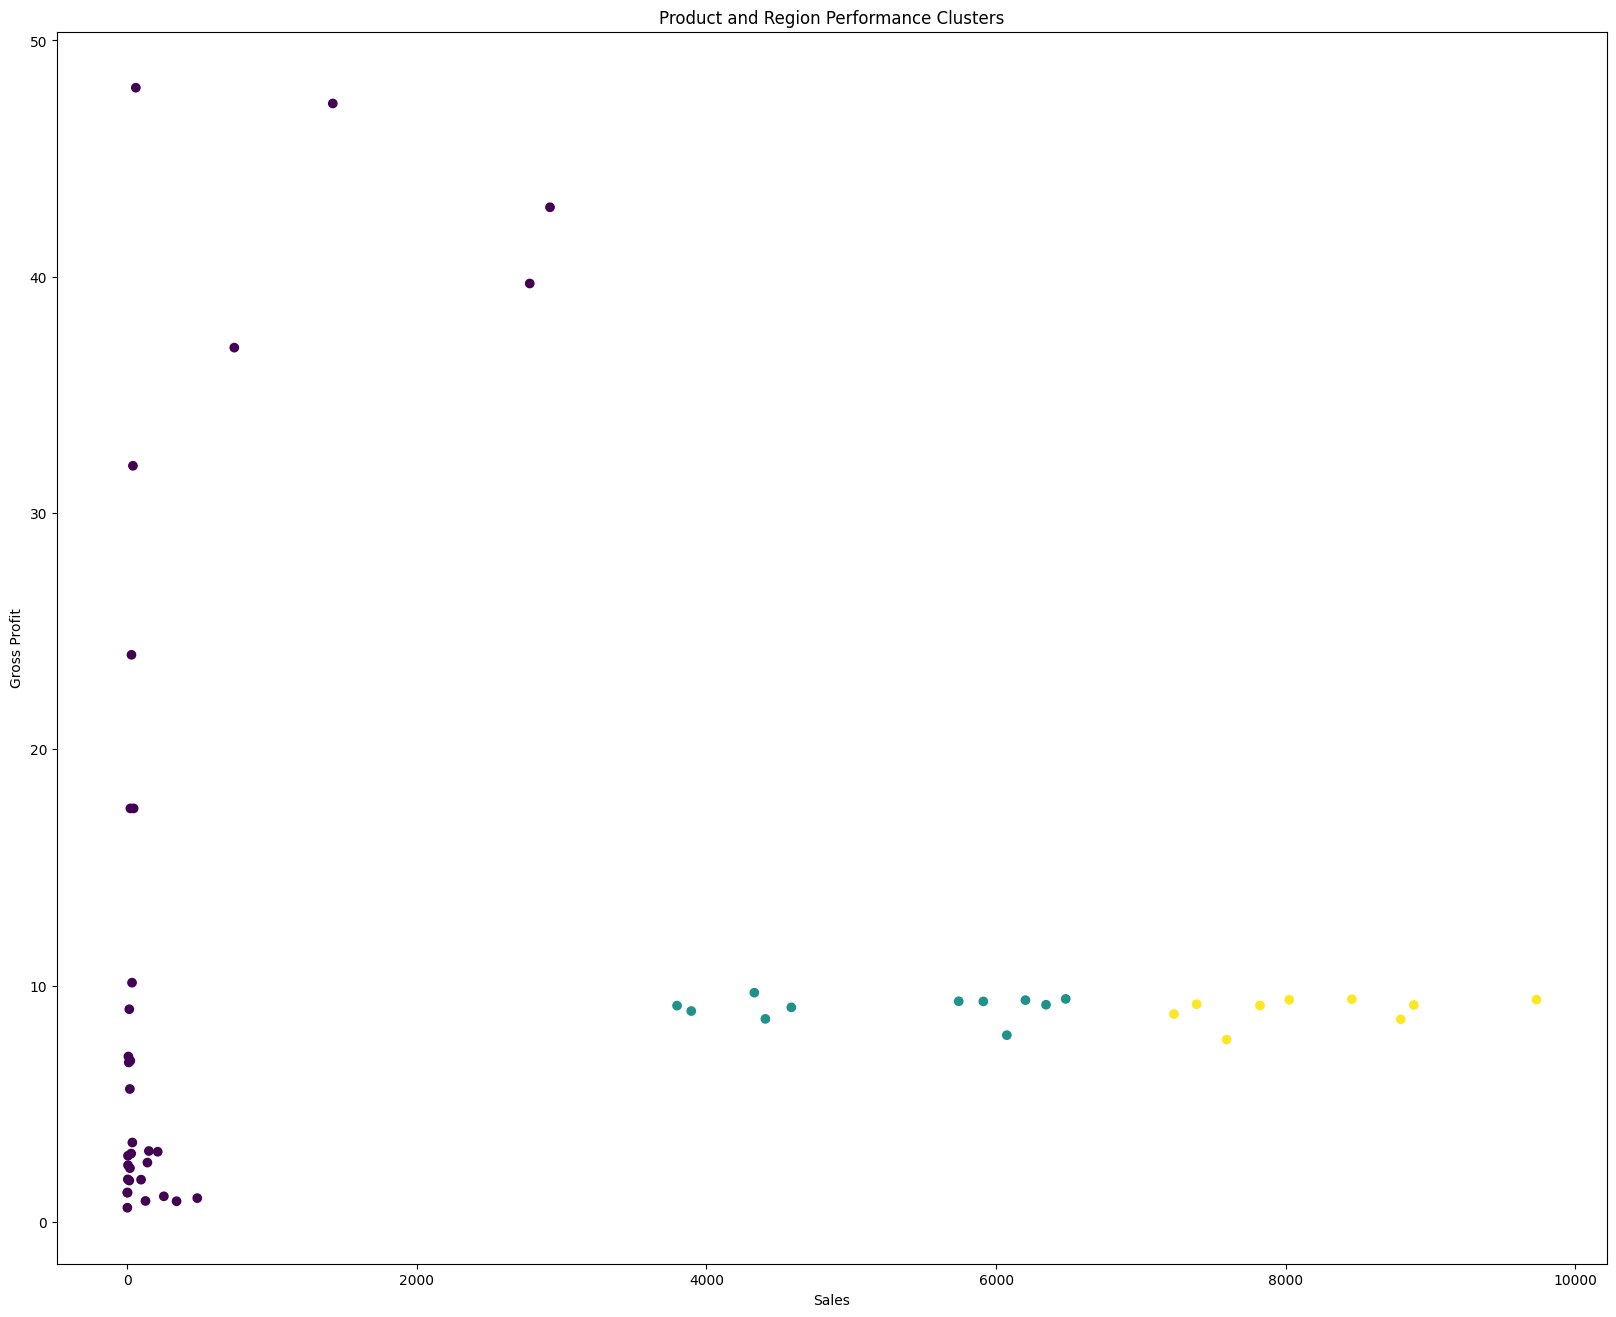

In [28]:
# visualize product and region performance clusters
import matplotlib.pyplot as plt

# Create scatter plot for clusters
plt.figure(figsize=(20,16))

scatter = plt.scatter(
    region_product_summary['Sales'],
    region_product_summary['Gross Profit'],
    c=region_product_summary['Cluster']
)

plt.xlabel('Sales')
plt.ylabel('Gross Profit')
plt.title('Product and Region Performance Clusters')

plt.show()

In [29]:
# simulate factory reassignment scenarios and estimate operational impact
# Create current performance summary
current_performance = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'mean',
    'Units': 'sum'
}).reset_index()

# Create recommended performance (simulation)
recommended_performance = current_performance.copy()

# Simulate improvement
recommended_performance['Sales'] = (
    recommended_performance['Sales'] * 1.10
)

recommended_performance['Gross Profit'] = (
    recommended_performance['Gross Profit'] * 1.05
)

# Compare current vs recommended
scenario_comparison = pd.DataFrame({
    'Product Name': current_performance['Product Name'],
    'Current Sales': current_performance['Sales'],
    'Recommended Sales': recommended_performance['Sales'],
    'Current Gross Profit': current_performance['Gross Profit'],
    'Recommended Gross Profit': recommended_performance['Gross Profit']
})

# Show first rows
print(scenario_comparison.head())

             Product Name  Current Sales  Recommended Sales  \
0  Everlasting Gobstopper         130.00            143.000   
1    Fizzy Lifting Drinks          78.75             86.625   
2                 Fun Dip          12.00             13.200   
3             Hair Toffee          76.50             84.150   
4               Kazookles        1205.75           1326.325   

   Current Gross Profit  Recommended Gross Profit  
0             34.666667                 36.400000  
1              7.875000                  8.268750  
2              1.600000                  1.680000  
3             14.875000                 15.618750  
4              0.966146                  1.014453  


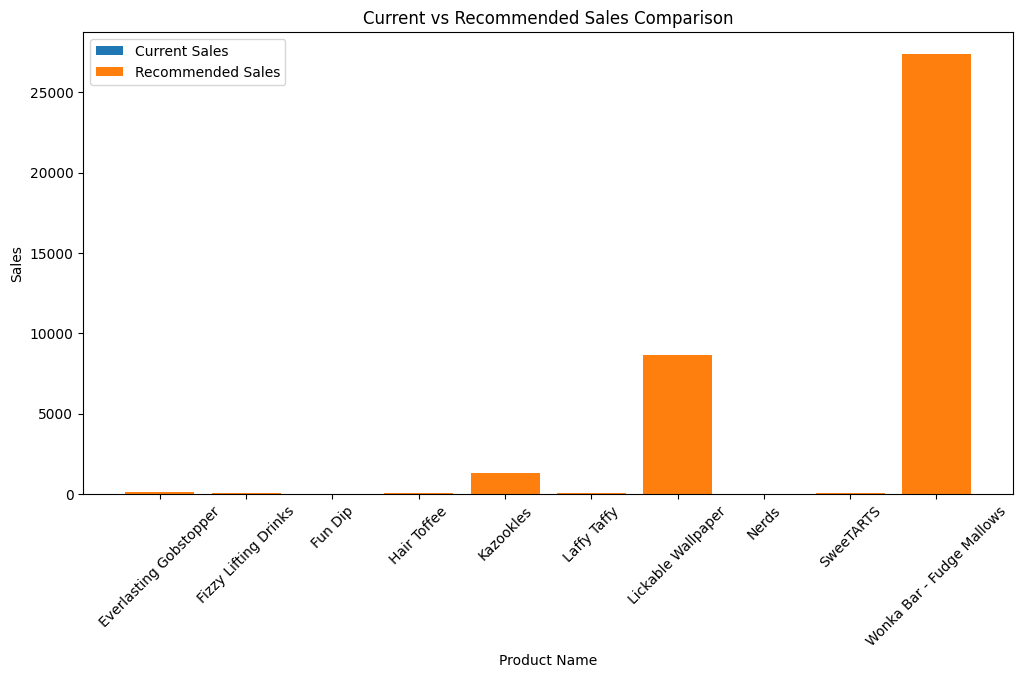

In [30]:
# compare current and recommended sales performance
import matplotlib.pyplot as plt

# Select top 10 products for visualization
top_scenarios = scenario_comparison.head(10)

# Plot comparison chart
plt.figure(figsize=(12,6))

x = range(len(top_scenarios))

plt.bar(
    x,
    top_scenarios['Current Sales'],
    label='Current Sales'
)

plt.bar(
    x,
    top_scenarios['Recommended Sales'],
    label='Recommended Sales'
)

plt.xticks(
    x,
    top_scenarios['Product Name'],
    rotation=45
)

plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Current vs Recommended Sales Comparison')
plt.legend()

plt.show()

In [31]:
# generate final factory optimization recommendatiomns based on business impact

# Create optimization score
scenario_comparison['Optimization Score'] = (
    scenario_comparison['Recommended Sales'] -
    scenario_comparison['Current Sales']
) + (
    scenario_comparison['Recommended Gross Profit'] -
    scenario_comparison['Current Gross Profit']
)

# Rank recommendations
final_recommendations = scenario_comparison.sort_values(
    by='Optimization Score',
    ascending=False
)

# Show top 10 recommendations
print(final_recommendations.head(10))

                         Product Name  Current Sales  Recommended Sales  \
12  Wonka Bar - Triple Dazzle Caramel       28485.00          31333.500   
13     Wonka Bar -Scrumdiddlyumptious       27874.80          30662.280   
10         Wonka Bar - Milk Chocolate       26867.75          29554.525   
9           Wonka Bar - Fudge Mallows       24890.40          27379.440   
11  Wonka Bar - Nutty Crunch Surprise       23574.95          25932.445   
6                  Lickable Wallpaper        7860.00           8646.000   
4                           Kazookles        1205.75           1326.325   
14                          Wonka Gum         597.50            657.250   
0              Everlasting Gobstopper         130.00            143.000   
3                         Hair Toffee          76.50             84.150   

    Current Gross Profit  Recommended Gross Profit  Optimization Score  
12              9.235831                  9.697623         2848.961792  
13              9.378634    